### Joining to Census Data

Data from the US Census Bureau provides a wealth of info about demographics on people and households. The most common sources of the data do not provide geometries, so you must join the data to the geometry FIRST. Then continue with your analysis.

In this example we pull data using the census library https://pypi.org/project/census/

Then join to geojson (pulled from DCP's website, you will notice there are issue).

We will then use the joined data to find areas we can do outreach at using overpass, then adminstative data from the state's open data portal.

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
# let's first get census data, we an either use the website or other library.
!pip install census

In [3]:
from census import Census
c = Census('f9cbc4b3a489f352112165af1e9aa8a5d7586f55')
variables = ("NAME", "B22003_001E", "B22003_002E", "B22003_005E")

In [4]:
data = c.acs5.state_county_tract(
    fields=variables,
    state_fips='36', 
    county_fips="061",
    tract=Census.ALL
)

In [5]:
data

[{'NAME': 'Census Tract 1; New York County; New York',
  'B22003_001E': 0.0,
  'B22003_002E': 0.0,
  'B22003_005E': 0.0,
  'state': '36',
  'county': '061',
  'tract': '000100'},
 {'NAME': 'Census Tract 2.01; New York County; New York',
  'B22003_001E': 852.0,
  'B22003_002E': 518.0,
  'B22003_005E': 334.0,
  'state': '36',
  'county': '061',
  'tract': '000201'},
 {'NAME': 'Census Tract 2.02; New York County; New York',
  'B22003_001E': 3163.0,
  'B22003_002E': 1347.0,
  'B22003_005E': 1816.0,
  'state': '36',
  'county': '061',
  'tract': '000202'},
 {'NAME': 'Census Tract 5; New York County; New York',
  'B22003_001E': 0.0,
  'B22003_002E': 0.0,
  'B22003_005E': 0.0,
  'state': '36',
  'county': '061',
  'tract': '000500'},
 {'NAME': 'Census Tract 6; New York County; New York',
  'B22003_001E': 5393.0,
  'B22003_002E': 2495.0,
  'B22003_005E': 2898.0,
  'state': '36',
  'county': '061',
  'tract': '000600'},
 {'NAME': 'Census Tract 7; New York County; New York',
  'B22003_001E': 522

In [6]:
tract_data = pd.DataFrame(data)

In [7]:
tract_data['GEOID'] = tract_data['state'] + tract_data['county'] + tract_data['tract']

In [8]:
tract_data['GEOID']

0      36061000100
1      36061000201
2      36061000202
3      36061000500
4      36061000600
          ...     
305    36061030900
306    36061031100
307    36061031703
308    36061031704
309    36061031900
Name: GEOID, Length: 310, dtype: str

In [9]:
tract_geom = gpd.read_file('./nyct2020_26b/nyct2020.shp')

In [10]:
tract_geom.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [11]:
tracts_mn = tract_geom[tract_geom['BoroCode'] == '1'].copy()

<Axes: >

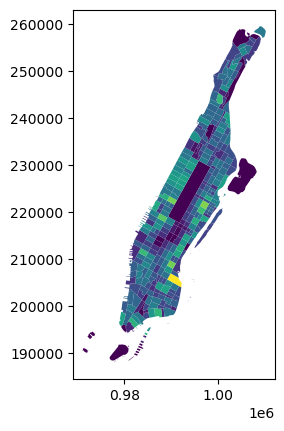

In [12]:
tracts_mn.merge(tract_data, how = 'right', right_on = 'tract', left_on = 'CT2020').plot('B22003_001E')

In [13]:
tracts_mn_with_snap = gpd.GeoDataFrame(tract_data.merge(tracts_mn, how = 'left', left_on = 'tract', right_on = 'CT2020'))

In [14]:
tracts_mn_with_snap['percent_snap'] = tracts_mn_with_snap['B22003_002E'] / tracts_mn_with_snap['B22003_001E']

In [15]:
tracts_mn_with_snap['percent_snap'].describe()

count    301.000000
mean       0.146607
std        0.160107
min        0.000000
25%        0.020772
50%        0.075518
75%        0.246054
max        0.826087
Name: percent_snap, dtype: float64

<Axes: >

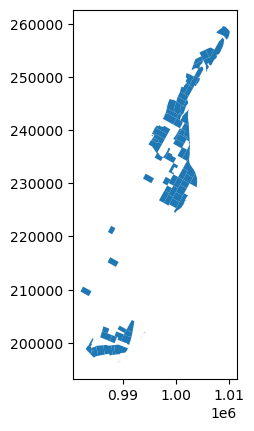

In [16]:
tracts_mn_with_snap[tracts_mn_with_snap['percent_snap'] > 0.25].plot()

In [17]:
tracts_mn_with_snap[['geometry', 'percent_snap']].fillna(0).set_crs(2263).to_crs(4326)

,geometry,percent_snap
0,"MULTIPOLYGON (((-74.04388 40.69019, -74.04351 ...",0.000000
1,"POLYGON ((-73.9845 40.70951, -73.9864 40.70933...",0.607981
2,"MULTIPOLYGON (((-73.98237 40.70554, -73.98246 ...",0.425862
3,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ...",0.000000
4,"POLYGON ((-73.99022 40.7144, -73.98934 40.7141...",0.462637
...,...,...
305,"POLYGON ((-73.90682 40.87659, -73.90665 40.875...",0.425931
306,"POLYGON ((-73.92234 40.85568, -73.9223 40.8556...",0.000000
307,"POLYGON ((-74.01273 40.71711, -74.01292 40.716...",0.015725
308,"POLYGON ((-74.01662 40.71216, -74.01658 40.712...",0.054239


In [18]:
# import geojson from overpass !!

In [19]:
supermarket = gpd.read_file('./supermarket.geojson')

In [20]:
supermarket_snap = supermarket.sjoin(tracts_mn_with_snap[['geometry', 'percent_snap']].fillna(0).set_crs(2263).to_crs(4326))

In [21]:
supermarket_snap[supermarket_snap['percent_snap'] > 0.5].explore()

In [22]:
### overpass function if we want automation

import requests
import geopandas as gpd

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

def query_overpass(
    bbox: tuple,
    tags: dict,
    element_types: list[str] = ["node", "way", "relation"]
) -> dict:
    south, west, north, east = bbox
    bbox_str = f"({south},{west},{north},{east})"
    tag_str = "".join(f"[{k}={v}]" for k, v in tags.items())

    statements = "\n".join(
        f"  {el}{tag_str}{bbox_str};" for el in element_types
    )

    query = f"""
    [out:json][timeout:25];
    (
    {statements}
    );
    out geom;
    """

    response = requests.get(
        OVERPASS_URL,
        params={"data": query},
        headers={"User-Agent": "python-app/1.0"},
        timeout=30
    )
    response.raise_for_status()

    return elements_to_geojson(response.json().get("elements", []))


def elements_to_geojson(elements: list[dict]) -> dict:
    """Convert a list of Overpass API elements to a GeoJSON FeatureCollection."""
    features = []

    for el in elements:
        el_type = el.get("type")
        props = {**el.get("tags", {}), "osm_id": el.get("id"), "osm_type": el_type}

        if el_type == "node":
            geometry = {
                "type": "Point",
                "coordinates": [el["lon"], el["lat"]]
            }

        elif el_type == "way":
            coords = [[n["lon"], n["lat"]] for n in el.get("geometry", [])]
            # Close the ring if the way is a polygon
            is_polygon = coords and coords[0] == coords[-1]
            geometry = {
                "type": "Polygon" if is_polygon else "LineString",
                "coordinates": [coords] if is_polygon else coords
            }

        elif el_type == "relation":
            # Outer members become the polygon shell; inner members become holes
            outer, inner = [], []
            for member in el.get("members", []):
                ring = [[n["lon"], n["lat"]] for n in member.get("geometry", [])]
                if not ring:
                    continue
                if member.get("role") == "inner":
                    inner.append(ring)
                else:
                    outer.append(ring)
            geometry = {"type": "MultiPolygon" if len(outer) > 1 else "Polygon",
                        "coordinates": outer + inner}

        else:
            continue

        features.append({"type": "Feature", "geometry": geometry, "properties": props})

    return {"type": "FeatureCollection", "features": features}

In [23]:
geojson = query_overpass(
    bbox=(40.6738536, -74.024131, 40.7416114, -73.9182042), # (south, west, north, east) = (min_lat, min_lon, max_lat, max_lon)
    tags={"shop": "bakery"},
    element_types=["node"]
)

In [24]:
supermarket_1 =  gpd.GeoDataFrame.from_features(geojson["features"], crs = 4326)

In [25]:
supermarket_1.to_file('supermarket_1.geojson', driver = 'GeoJSON')

In [70]:
supermarket_1.explore()

In [ ]:
# other dataset, with better detail - https://data.ny.gov/Economic-Development/Retail-Food-Stores/9a8c-vfzj/about_data

# https://agriculture.ny.gov/division-weights-and-measures